In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker

from utils import get_data_and_init_dicts, get_sub_data_flow, append_and_process_results, visualize_results, run_MCMC, select_MCMC_chains

current_dir = os.getcwd()
module_path = os.path.abspath(os.path.join(current_dir, '../..', 'libs'))
if module_path not in sys.path:
    sys.path.append(module_path)

from SCOU_NC_Vanilla_NUTS_manual import *

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# SCOU hyperparameters:
NB_CHAINS = 10
TUNING_ITERS = 4000
SAMPLING_ITERS = 2000

# Raw dataset path:
filepath = '../../data/Observatory_paper_mendeley.xlsx'

In [3]:
step = 'CLICHY'
subraw_data, scou_dict, sub_data_dict, lods_dict, parameters_list = get_data_and_init_dicts(step, filepath)
common_flux_data = {}

In [4]:
dates_list = ['2021-07-20',
 '2021-08-17',
 '2021-09-14',
 '2021-10-12',
 '2021-11-16',
 '2021-12-14',
 '2022-01-18',
 '2022-02-15',
 '2022-03-15',
 '2022-04-12',
 '2022-08-23',
 '2022-09-13',
 '2022-10-11',
 '2022-11-15',
 '2022-12-13',
 '2023-01-17',
 '2023-02-14',
 '2023-03-14',
 '2023-04-18',
 '2023-05-16',
 '2023-06-13',
 '2023-07-18',
 '2023-08-22',
 '2023-09-19',
 '2023-10-17',
 '2023-11-14',
 '2023-12-12',
 '2024-02-13',
 '2024-03-19',
 '2024-04-16',
 '2024-05-21',
 '2024-06-18',
 '2024-07-16',
 '2024-08-20',
 '2024-09-17',
 '2024-10-15',
 '2024-11-19',
 '2024-12-17']

In [5]:
subraw_data = subraw_data.loc[subraw_data.dateStart.isin(dates_list)]

In [6]:
run_MCMC(subraw_data, lods_dict, scou_dict, ['MES'], step, get_sub_data_flow, False, TUNING_ITERS, SAMPLING_ITERS, NB_CHAINS)

Processing MES...


/opt/anaconda3/envs/pymc5/lib/python3.9/site-packages/pymc/distributions/timeseries.py:558: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100, shape=...)`. You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (10 chains in 4 jobs)
NUTS: [sig, eps, latent]


Sampling 10 chains for 4_000 tune and 2_000 draw iterations (40_000 + 20_000 draws total) took 708 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Raw summary:
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig  0.075  0.013   0.051    0.100      0.001    0.001     104.0     298.0   
eps  0.213  0.054   0.117    0.317      0.001    0.001    2761.0   10950.0   

     r_hat  
sig   1.07  
eps   1.01  


In [7]:
chain_selector_dict = {}
chain_selector_dict['MES'] = []

In [8]:
for this_parameter in parameters_list:
    sub_data = get_sub_data_flow(subraw_data, lods_dict, this_parameter, step, remove_outliers=False)
    sub_data_dict[this_parameter] = sub_data

Processing MES...


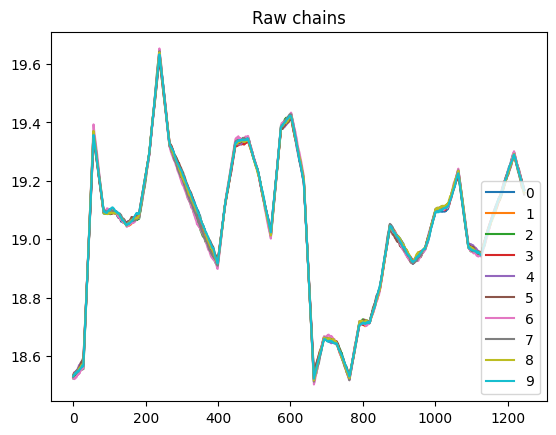

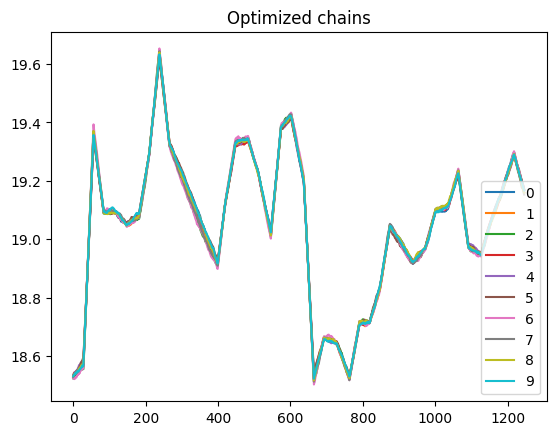

Best chain combination summary:
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig  0.075  0.013   0.051    0.100      0.001    0.001     104.0     298.0   
eps  0.213  0.054   0.117    0.317      0.001    0.001    2761.0   10950.0   

     r_hat  
sig   1.07  
eps   1.01  


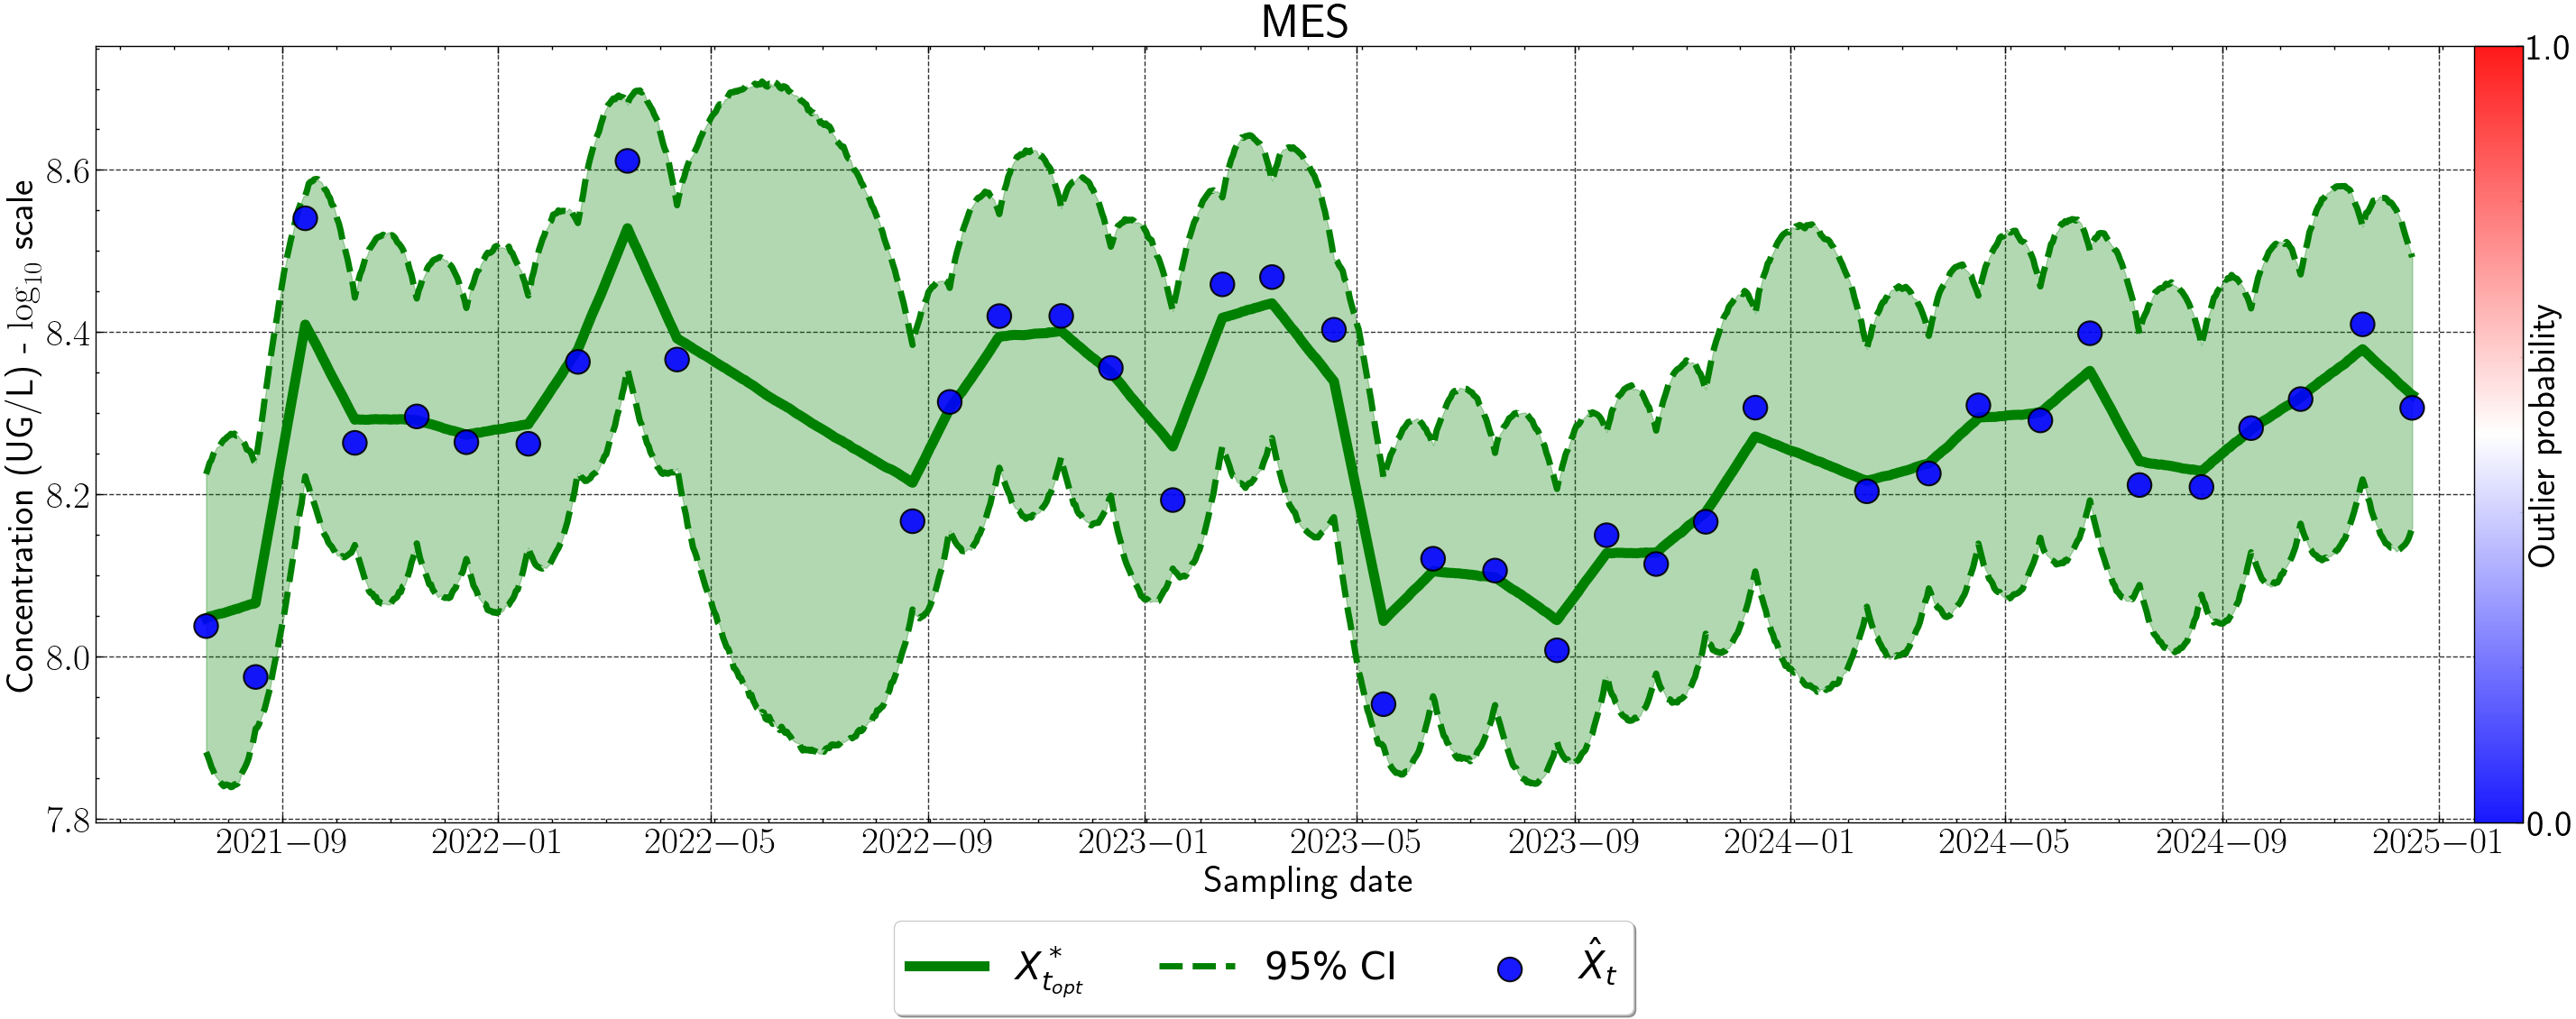

In [9]:
select_MCMC_chains(scou_dict, sub_data_dict, ['MES'], chain_selector_dict, common_flux_data, NB_CHAINS)

In [10]:
for parameter in list(common_flux_data.keys()):
    this_file = common_flux_data[parameter]
    this_file.to_csv(f'../../outputs/files/flow_data_MES_specific_calendar/{parameter}.csv', sep=';', index=False)